# Tariff War: US vs DK/EA

This notebook simulates the tariff extension. The scenario is a trade war where the **US imposes an initial tariff** on DK/EA exports (`tau_x`), and **DK/EA retaliates** with a tariff on US-origin materials (`tau_m`). Both shocks are very persistent AR(1) processes (ρ = 0.95).

We compare four scenarios:
1. **No tariffs** — baseline (flat IRFs)
2. **US tariff only** (`tau_x`) — US raises price of DK exports in the US market
3. **DK/EA retaliation only** (`tau_m`) — DK+EA raise price of US-origin materials
4. **Full tariff war** — both shocks simultaneously

## 1. Setup

In [2]:
%load_ext autoreload
%autoreload 2

import sys
import numpy as np
import matplotlib.pyplot as plt
import os

# GEModelTools and EconModel are local packages — add to path if not already installed
if r'c:\Users\kons-ana\GEModelTools' not in sys.path:
    sys.path.insert(0, r'c:\Users\kons-ana\GEModelTools')

from IHANKModel import IHANKModelClass

folder = 'tariff extension'
os.makedirs(folder, exist_ok=True)

# Plot style (matching existing notebooks)
plt.rcParams.update({'axes.grid': True, 'grid.color': 'black', 'grid.alpha': '0.25', 'grid.linestyle': '--'})
plt.rcParams.update({'font.size': 14})
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import os #save figures
folder_tariff = "tariff extension"
os.makedirs(folder_tariff, exist_ok=True)


import matplotlib.pyplot as plt   
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
plt.rcParams.update({"axes.grid" : True, "grid.color": "black", "grid.alpha":"0.25", "grid.linestyle": "--"})
plt.rcParams.update({'font.size': 14})

from IHANKModel import IHANKModelClass

## 2. Steady state

In [ ]:
# Create baseline model (all tariffs = 0 in SS — unchanged from pre-tariff model)

model = IHANKModelClass(name='baseline')

# Initialize tariff variables to 0 in steady state
par = model.par
ss = model.ss
path = model.path
sim = model.sim

par.float = False # float or fix exchange rate
model.find_ss(do_print=True)

household problem in ss solved in 2.5 secs [375 iterations]
household problem in ss simulated in 3.3 secs [419 iterations]
steady state found in 6.5 secs
ss.inc_TH = 0.175
ss.inc_NT = 0.525
par.alphaT = 0.355
par.alphaF = 0.333
par.varphiTH = 1.271
par.varphiNT = 1.271
ss.M_eu_s = 0.056
ss.M_us_s = 0.056
ss.clearing_YTH =   0.00000000
ss.clearing_YNT =   0.00000000
ss.G = 0.296
ss.NFA = 0.000
ss.CB = 1.000
ss.CB_us = 1.000


In [3]:
model.test_ss()

E              :       1.0000
CB             :       1.0000
E_us           :       1.0000
CB_us          :       1.0000
piM_eu_eu      :       0.0000
piM_us_us      :       0.0000
PM_eu_eu       :       1.0000
PM_us_us       :       1.0000
PM_eu_us       :       1.0000
PM_eu          :       1.0000
PM_us_eu       :       1.0000
PM_us          :       1.0000
PM_dk_eu       :       1.0000
PM_dk_us       :       1.0000
PM_dk          :       1.0000
tau_m          :       0.0000
tau_x          :       0.0000
Z_eu           :       1.0000
i_shock_eu     :       0.0000
Y_eu           :       1.1111
C_eu           :       1.0000
N_eu           :       1.0000
pi_eu          :       0.0000
i_eu           :       0.0050
PF_eu_s        :       1.0000
rF_eu          :       0.0050
M_eu_s         :       0.0556
mc_eu          :       1.0000
W_eu           :       1.0000
M_eu           :       0.1111
M_eu_eu        :       0.1000
M_eu_us        :       0.0111
eu_Euler_res   :       0.0000
eu_LS_res 

## 3. Compute Jacobians

Must be re-run after adding new shocks (`tau_m`, `tau_x`) to the model.

In [4]:
model.compute_jacs(do_print=True)

household Jacobians:
one step deviation from steady state calculated in 0.0 secs
curly_Y and curly_D calculated for beta            in 0.6 secs
curly_Y and curly_D calculated for inc_NT          in 0.5 secs
curly_Y and curly_D calculated for inc_TH          in 0.6 secs
curly_Y and curly_D calculated for ra              in 0.6 secs
curly_E calculated in 1.5 secs
builiding blocks combined in 0.6 secs
household Jacobian computed in 4.4 secs

full Jacobians:
full Jacobian to unknowns computed in 48.7 secs [in evaluate_blocks(): 36.0 secs]
full Jacobian to shocks computed in 16.1 secs [in evaluate_blocks(): 5.8 secs]


## 4. Tariff scenarios

Tariff size: **25%** (`jump = 0.25`), persistence: **ρ = 0.95**.

Each scenario is run on a fresh copy of the baseline model so parameter choices don't bleed across runs.

In [5]:
TARIFF_SIZE = 0.25   # 25% tariff
TARIFF_RHO  = 0.95   # persistence

### Scenario 2 — US initial tariff only (`tau_x`)

In [ ]:
m_tau_x = model.copy()
m_tau_x.par.jump_tau_x = TARIFF_SIZE
m_tau_x.par.rho_tau_x  = TARIFF_RHO

m_tau_x.find_transition_path(shocks=['tau_x'], do_print=True, do_end_check=False)

max |tau_x|: 0.25
### shocks ###


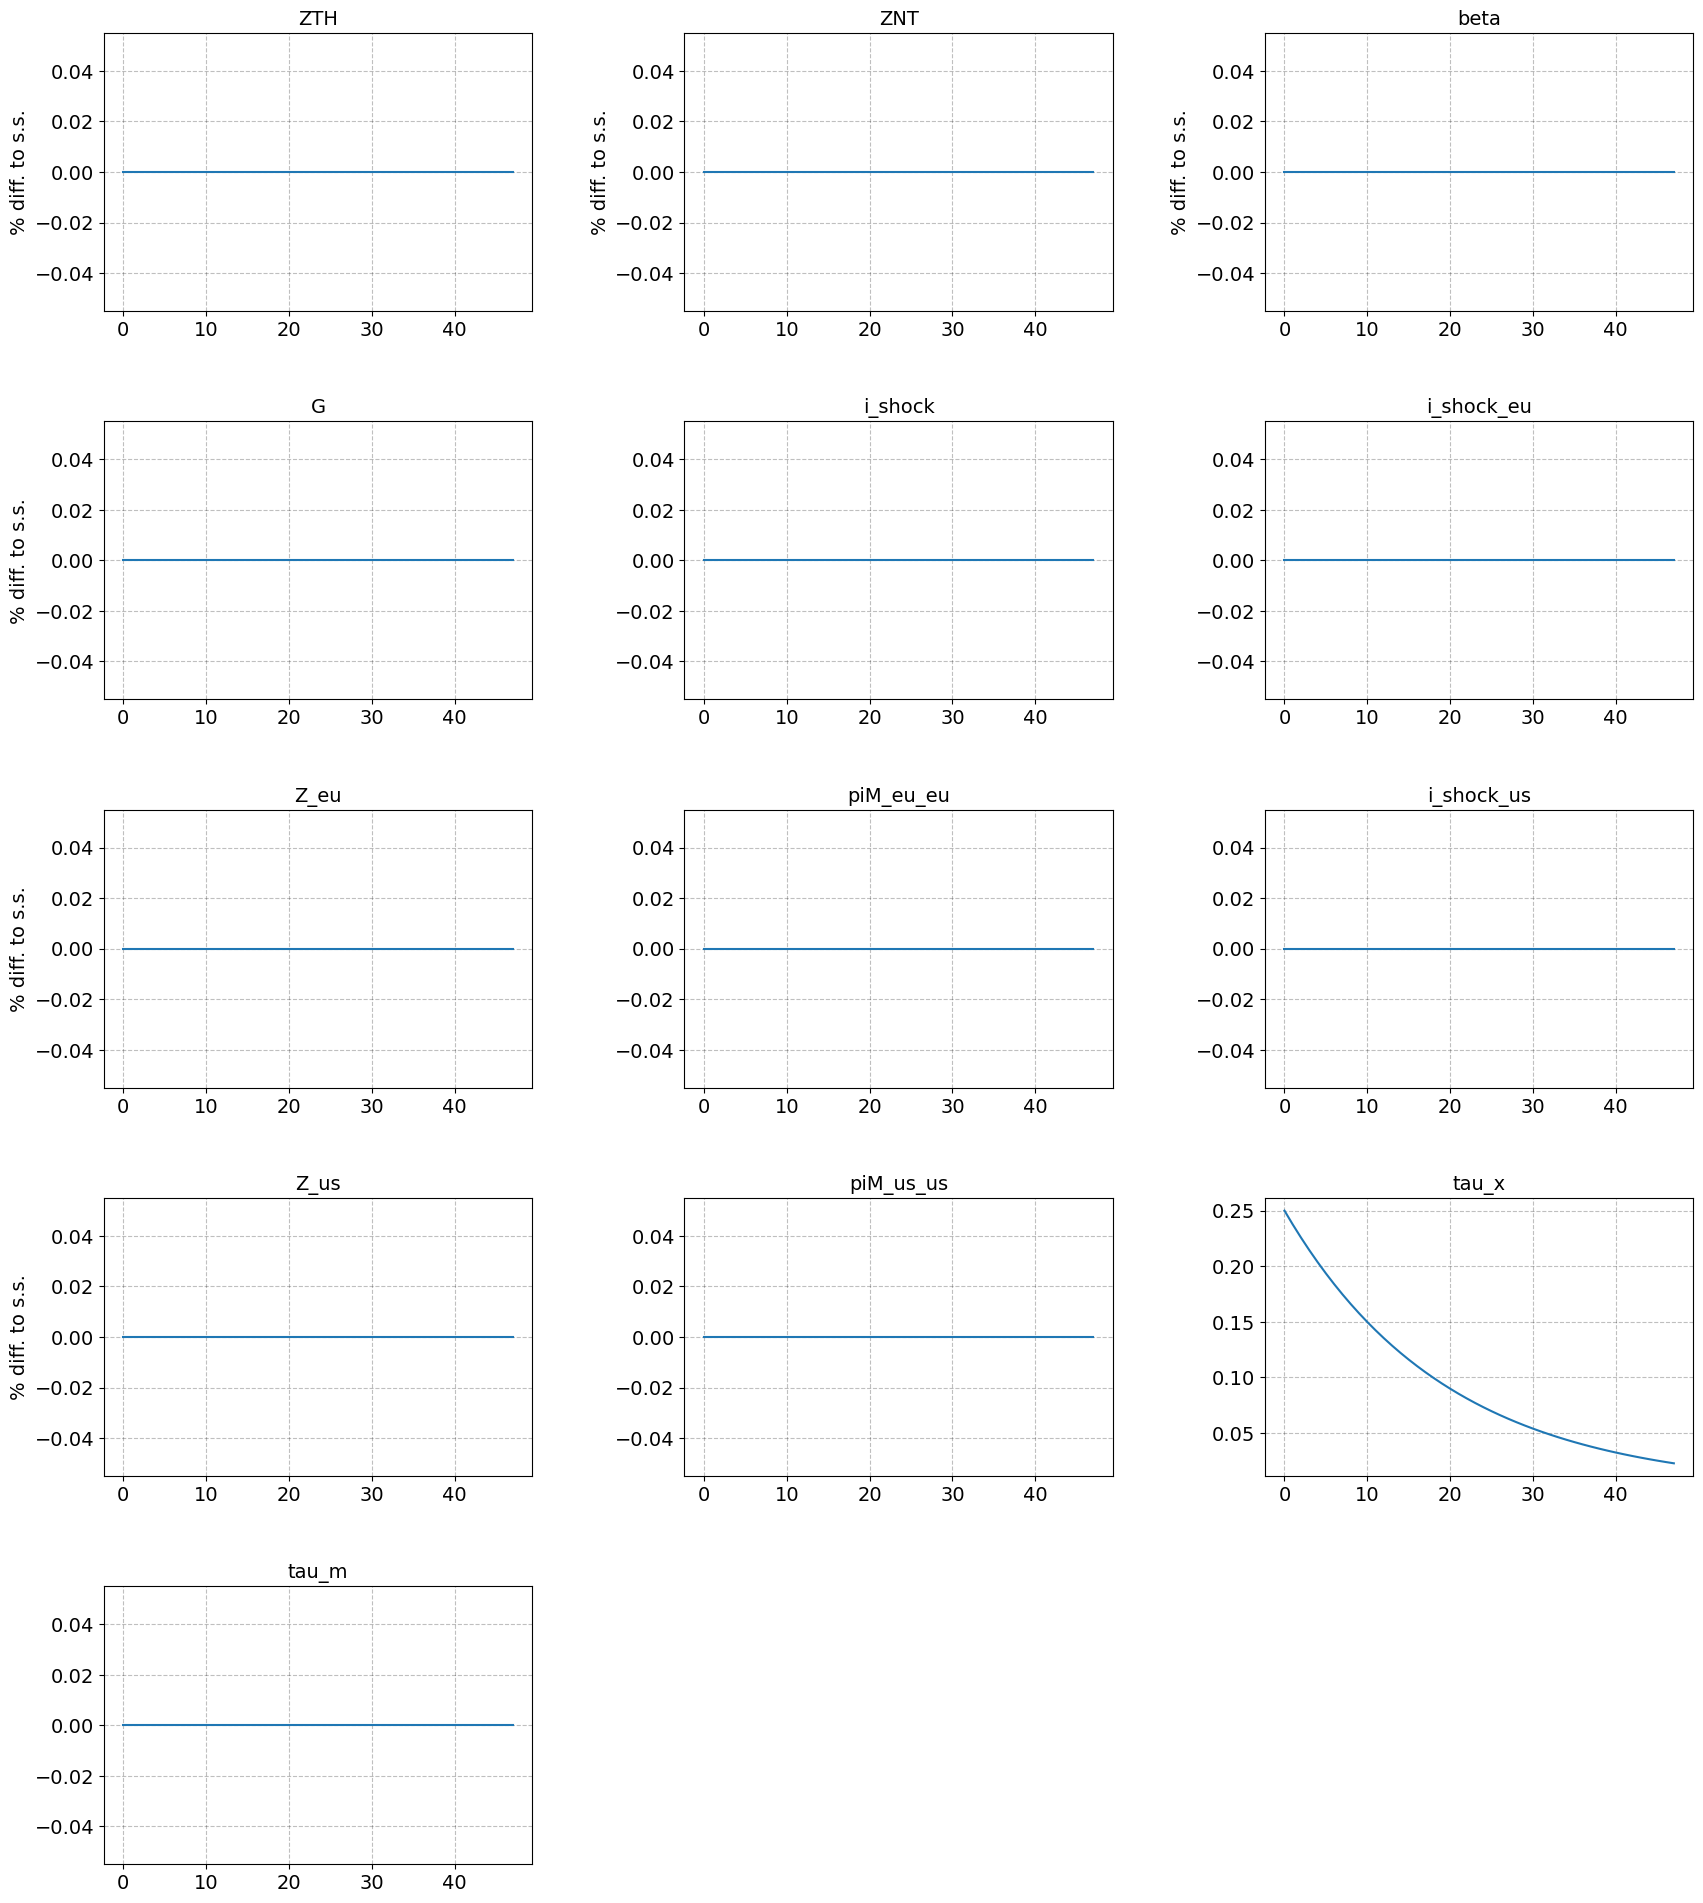


### varnames ###


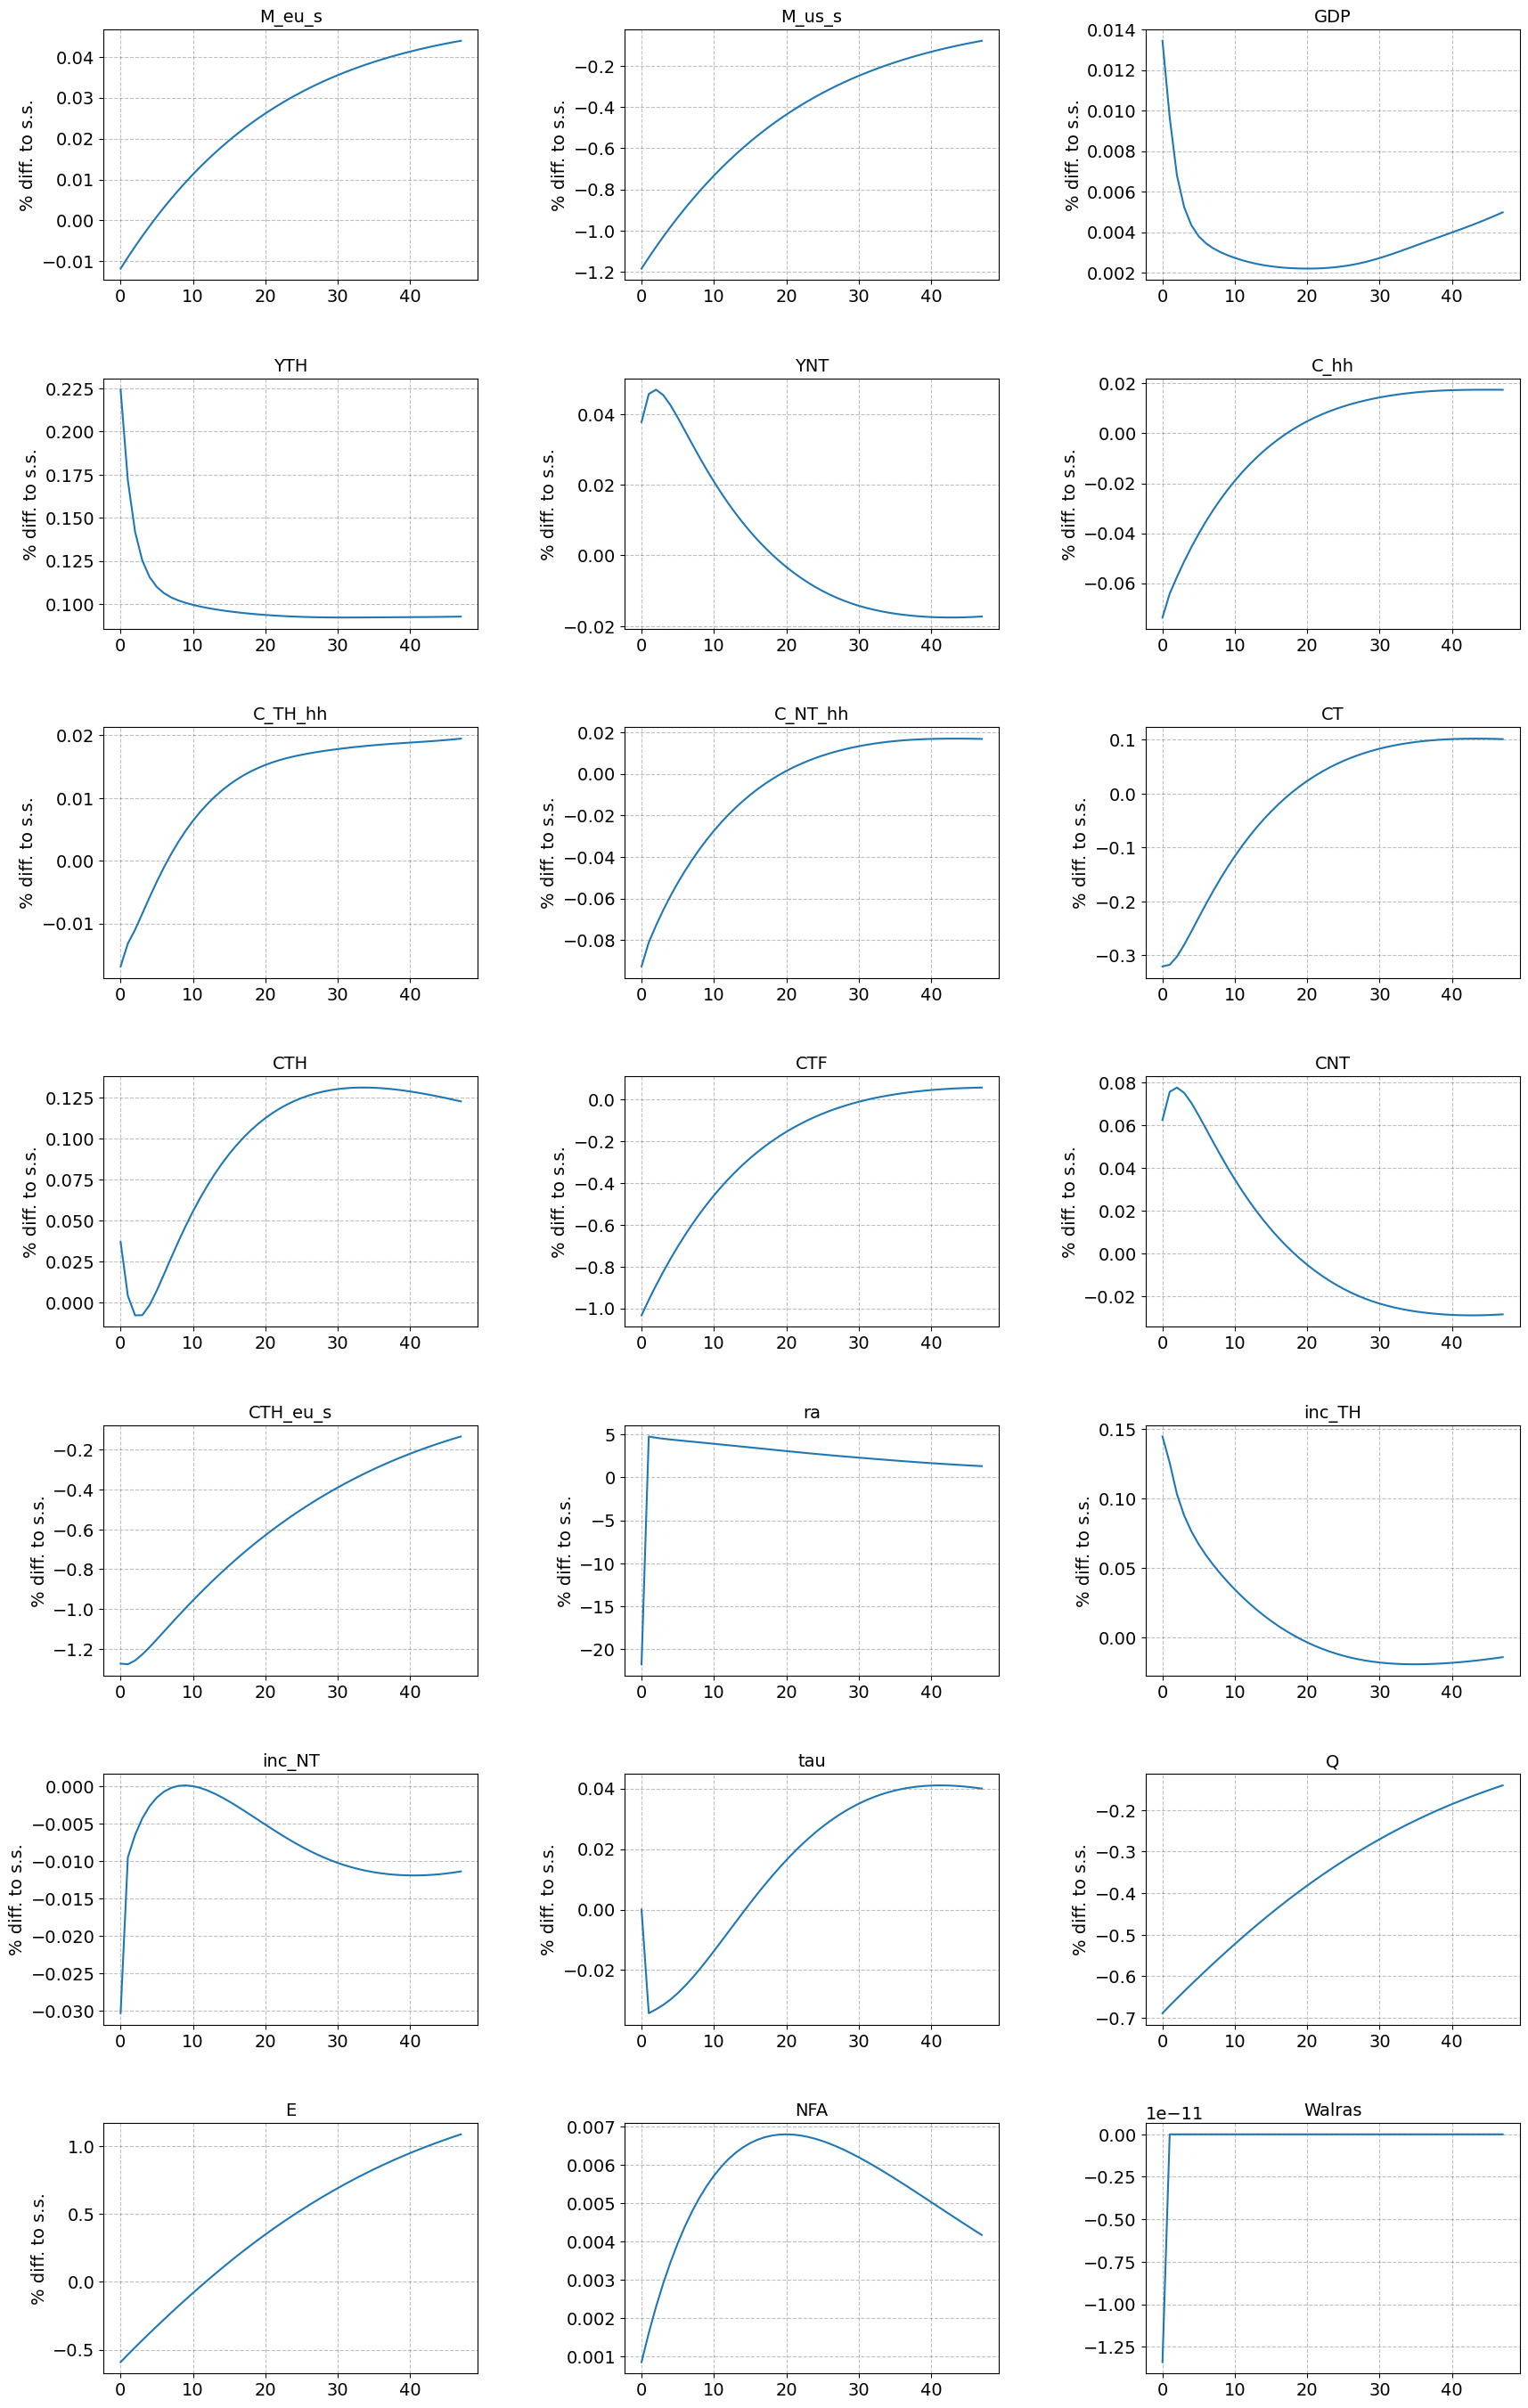


### tagets ###


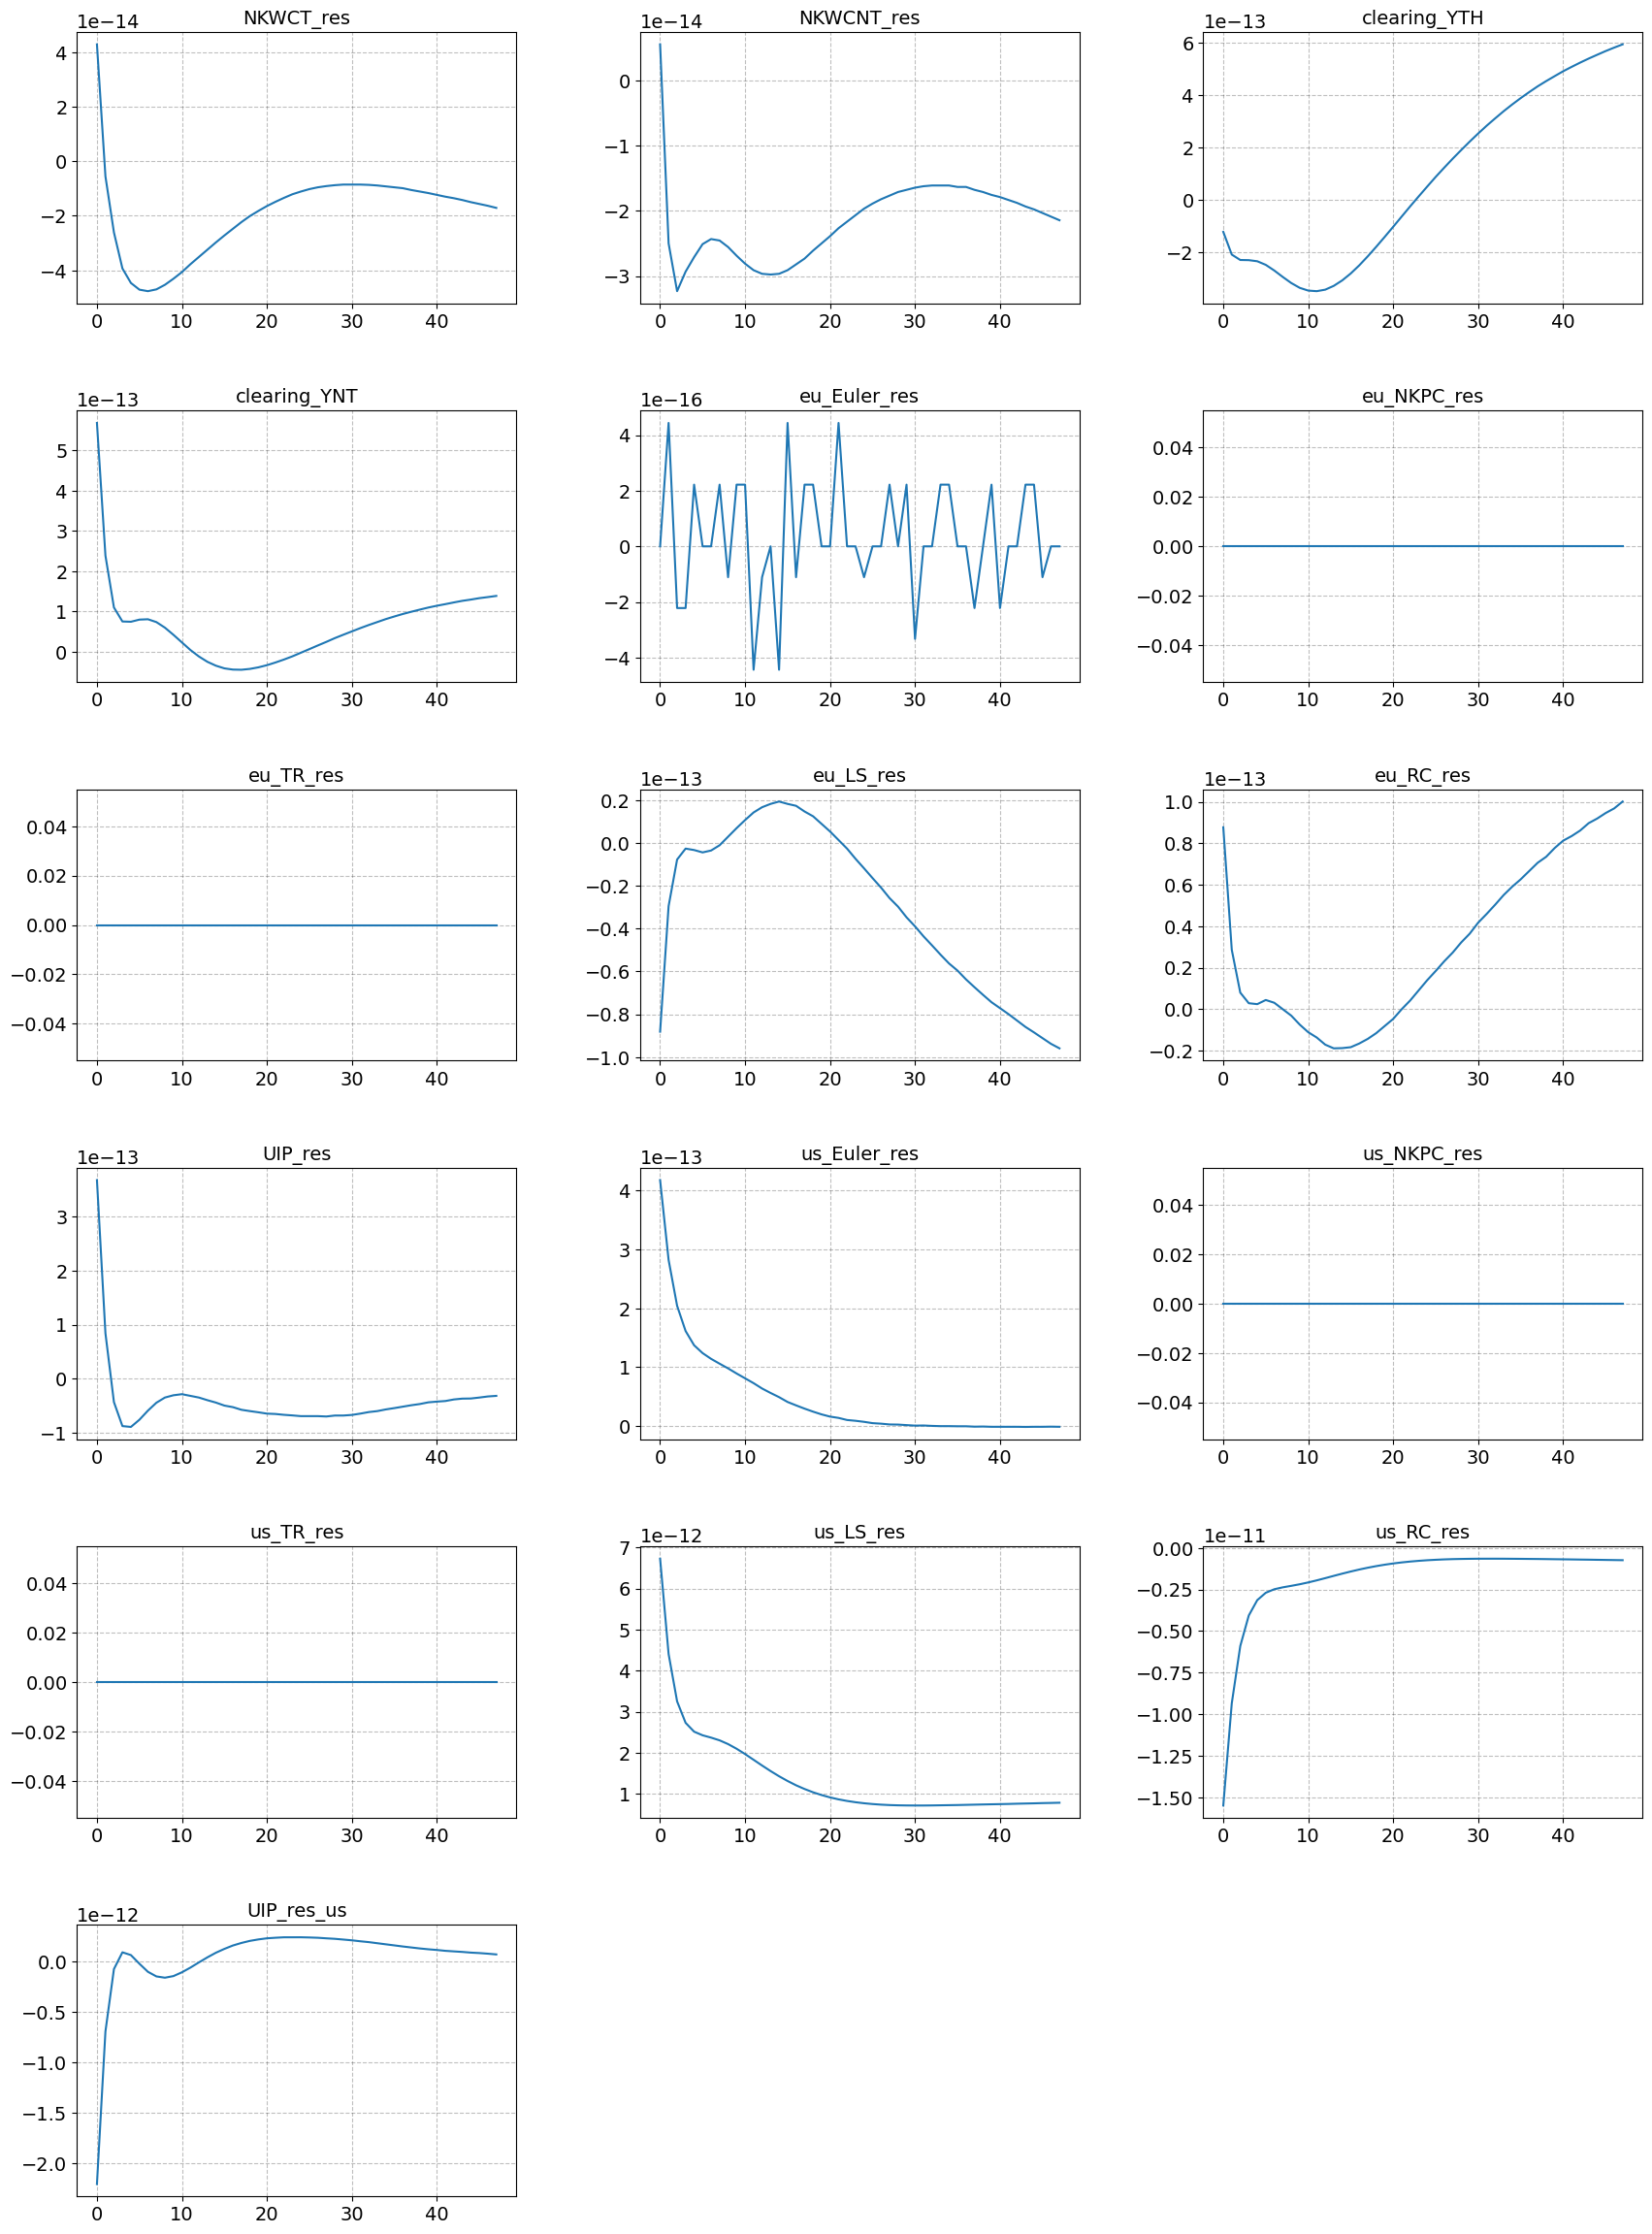

In [14]:

print("max |tau_x|:", np.max(np.abs(m_tau_x.path.tau_x)))


paths = ['M_eu_s','M_us_s','GDP','YTH','YNT','C_hh','C_TH_hh','C_NT_hh','CT','CTH','CTF','CNT','CTH_eu_s','ra','inc_TH','inc_NT','tau','Q','E','NFA','Walras']
lvl_value=['r','NFA','Walras','i_shock', 'i_shock_eu', 'i_shock_us', 'piM_us_us', 'piM_eu_eu', 'tau_x', 'tau_m']
m_tau_x.show_IRFs(paths,lvl_value=lvl_value,T_max=48,ncols=3)

### Scenario 3 — DK/EA retaliation only (`tau_m`)

In [15]:
m_tau_m = model.copy()
m_tau_m.par.jump_tau_m = TARIFF_SIZE
m_tau_m.par.rho_tau_m  = TARIFF_RHO

m_tau_m.find_transition_path(shocks=['tau_m'], do_print=False, do_end_check=False)

max |tau_m|: 0.25
### shocks ###


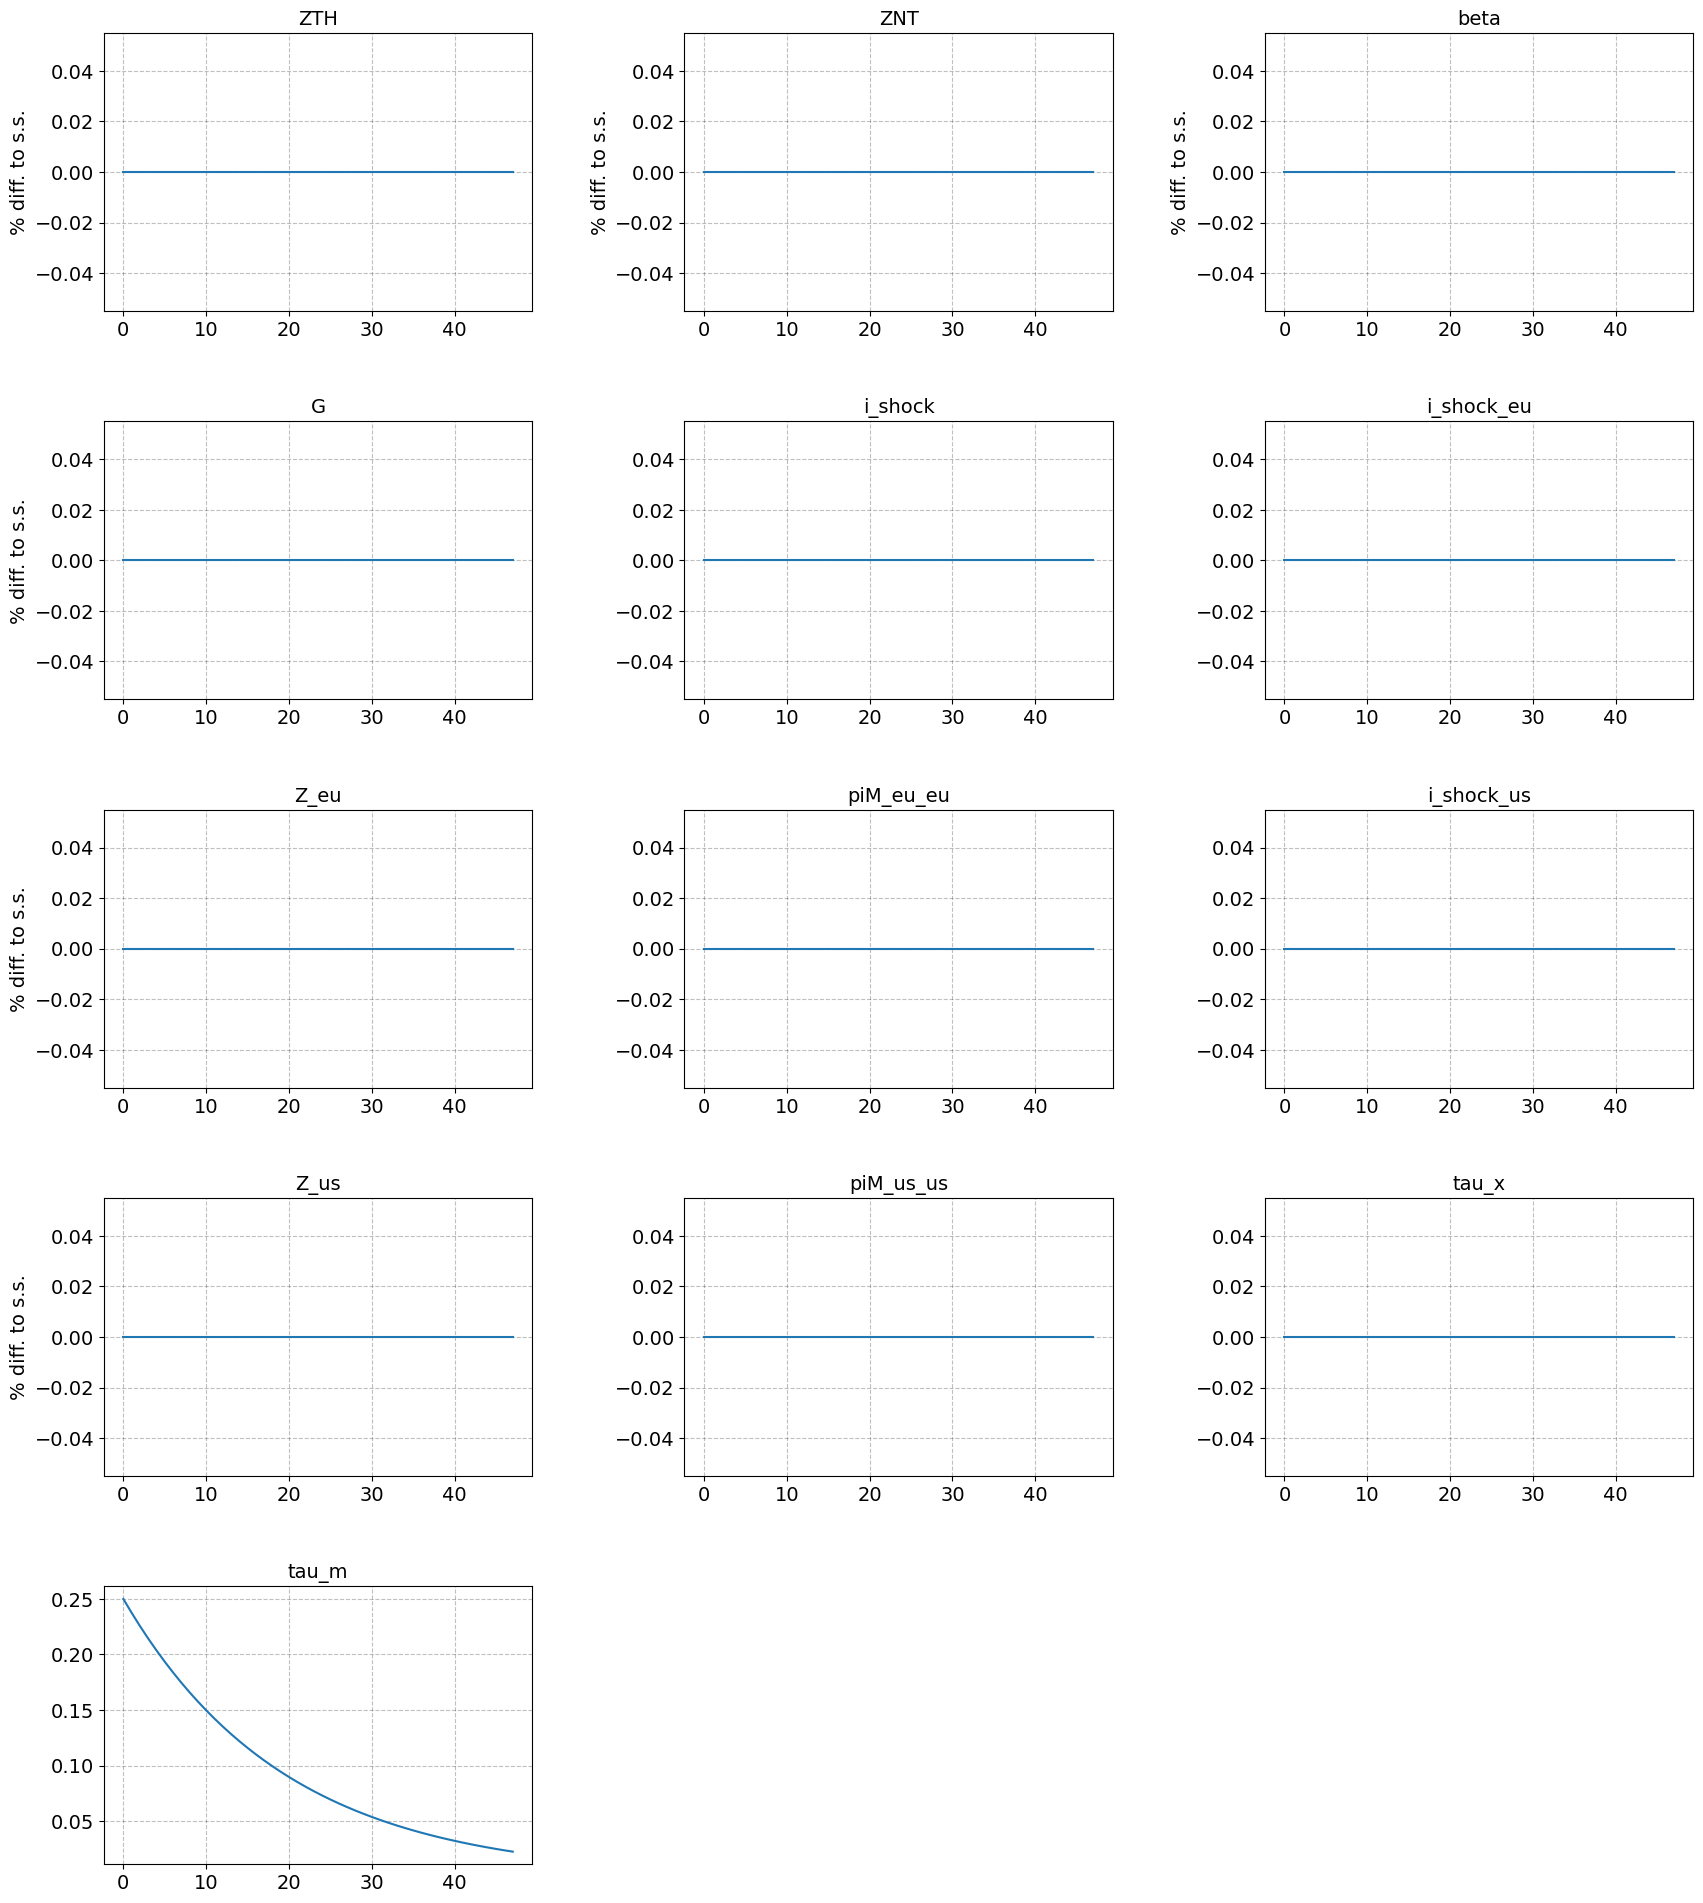


### varnames ###


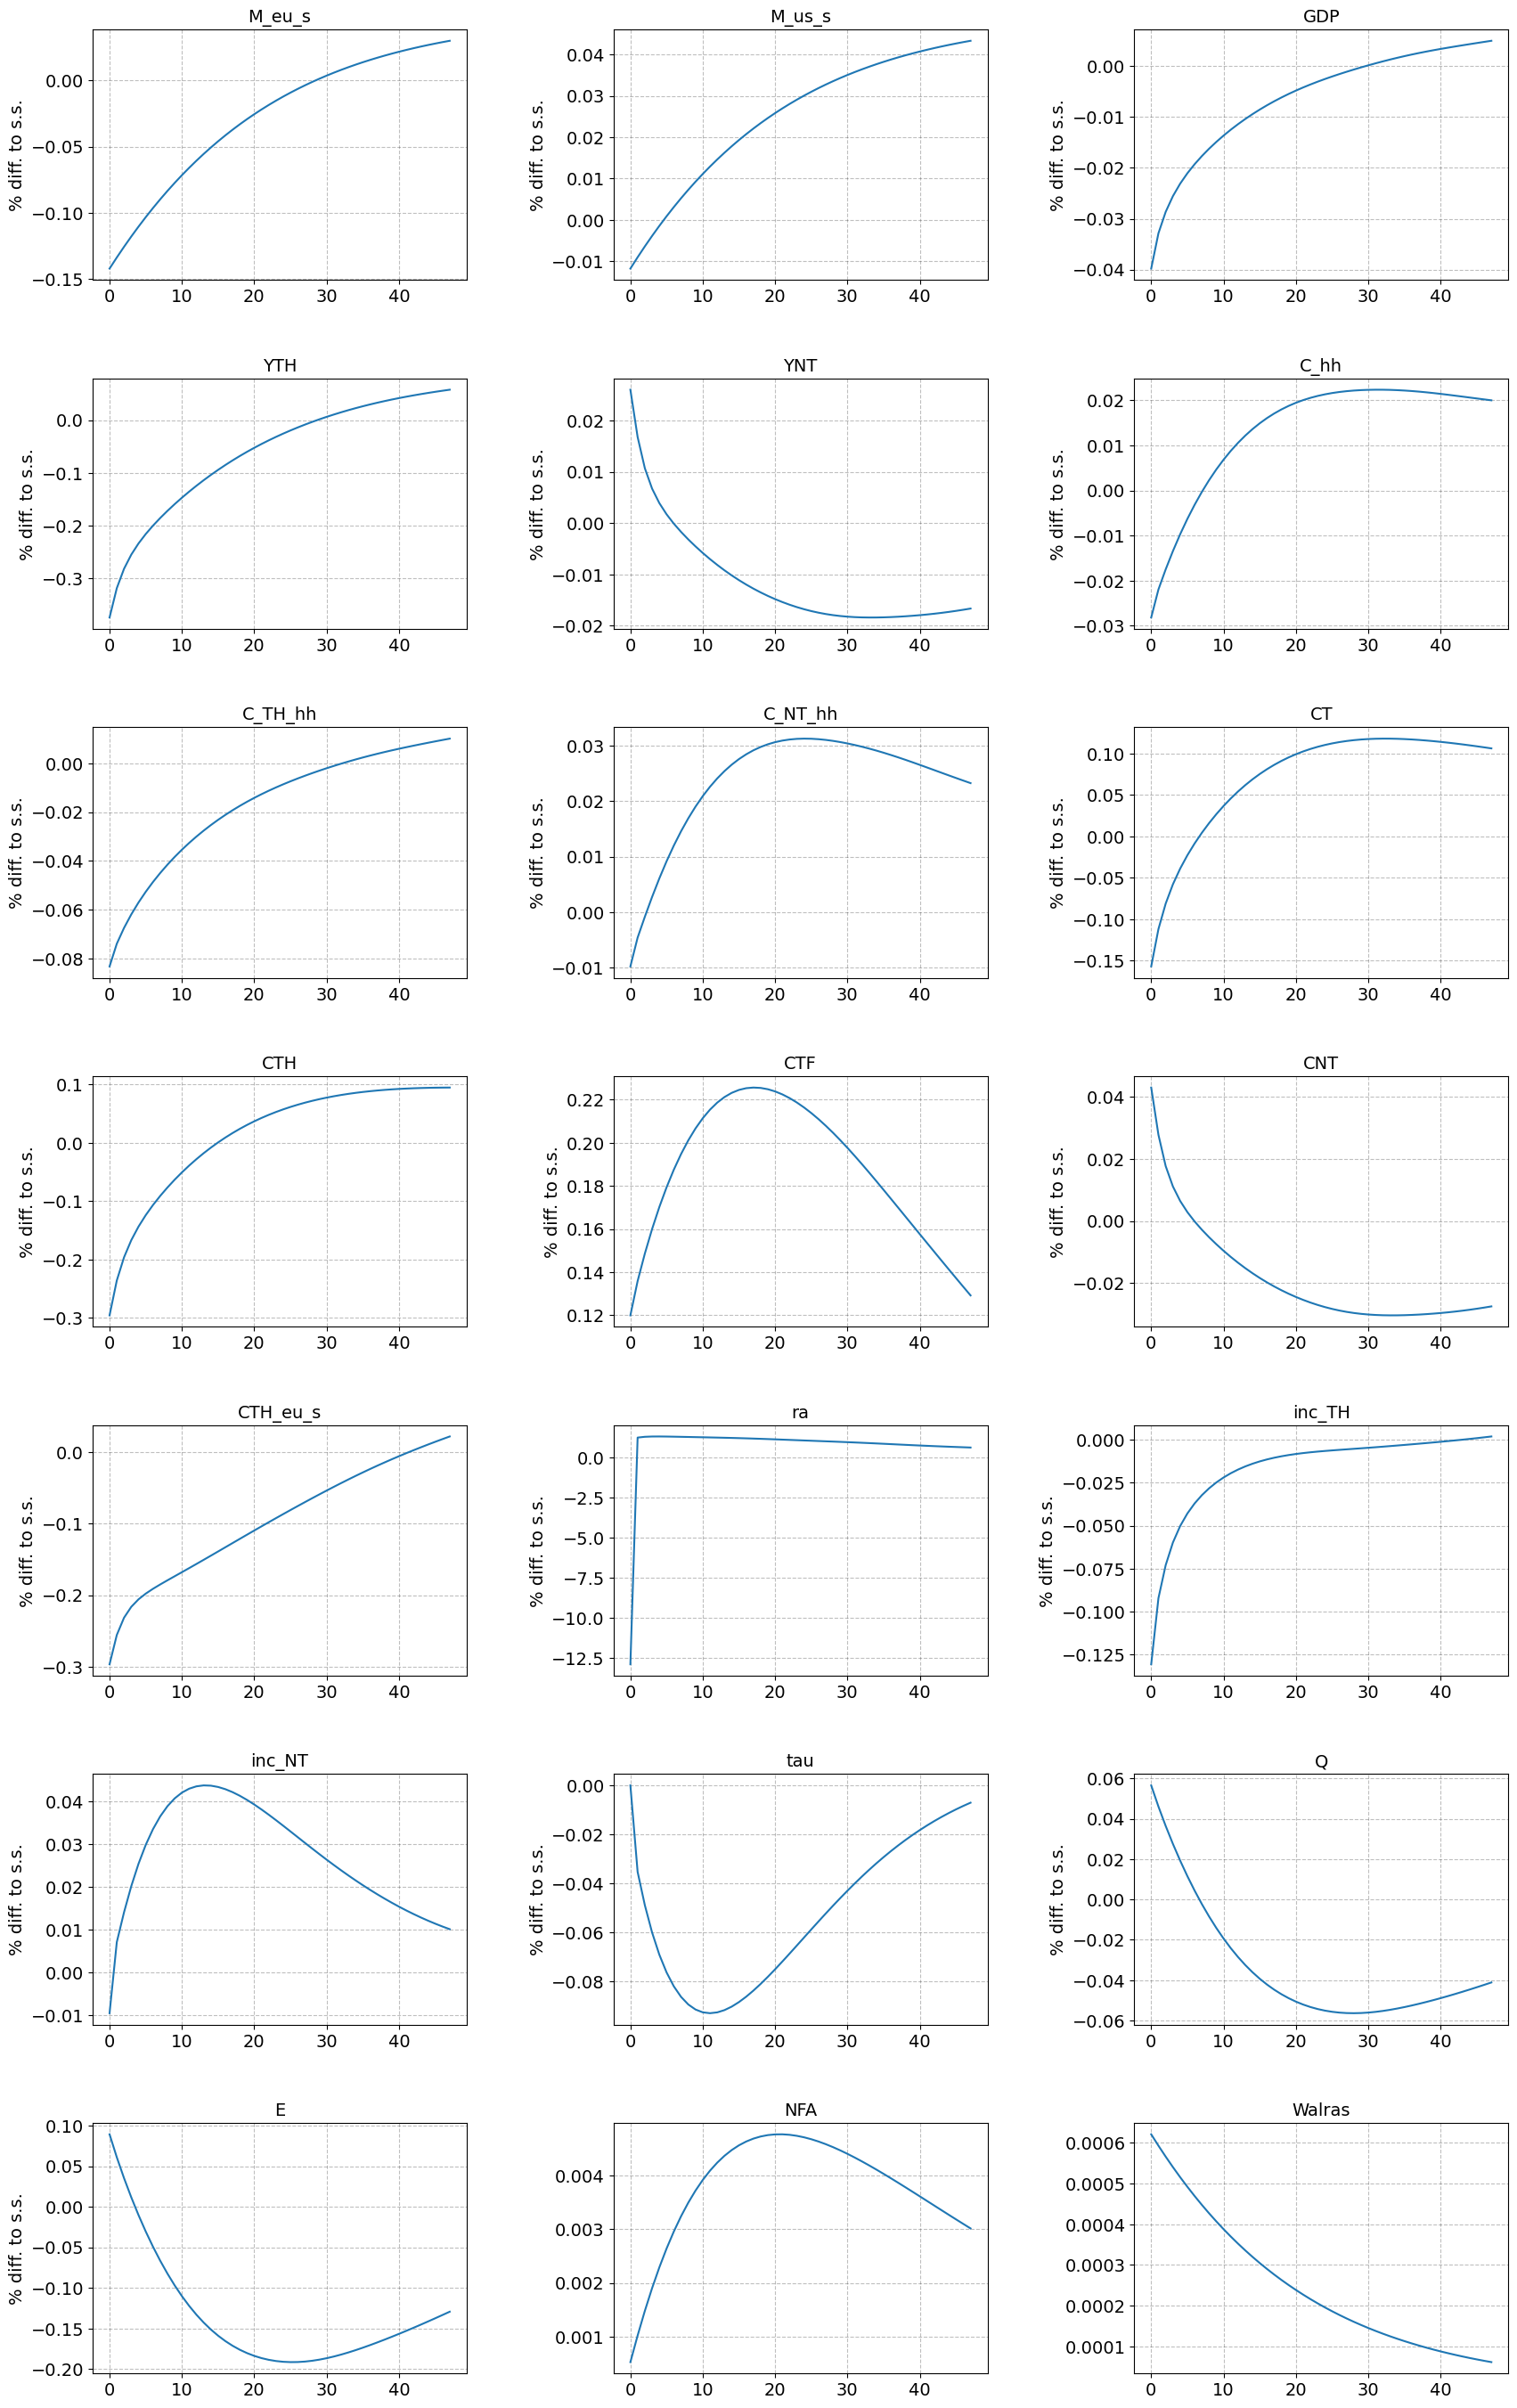


### tagets ###


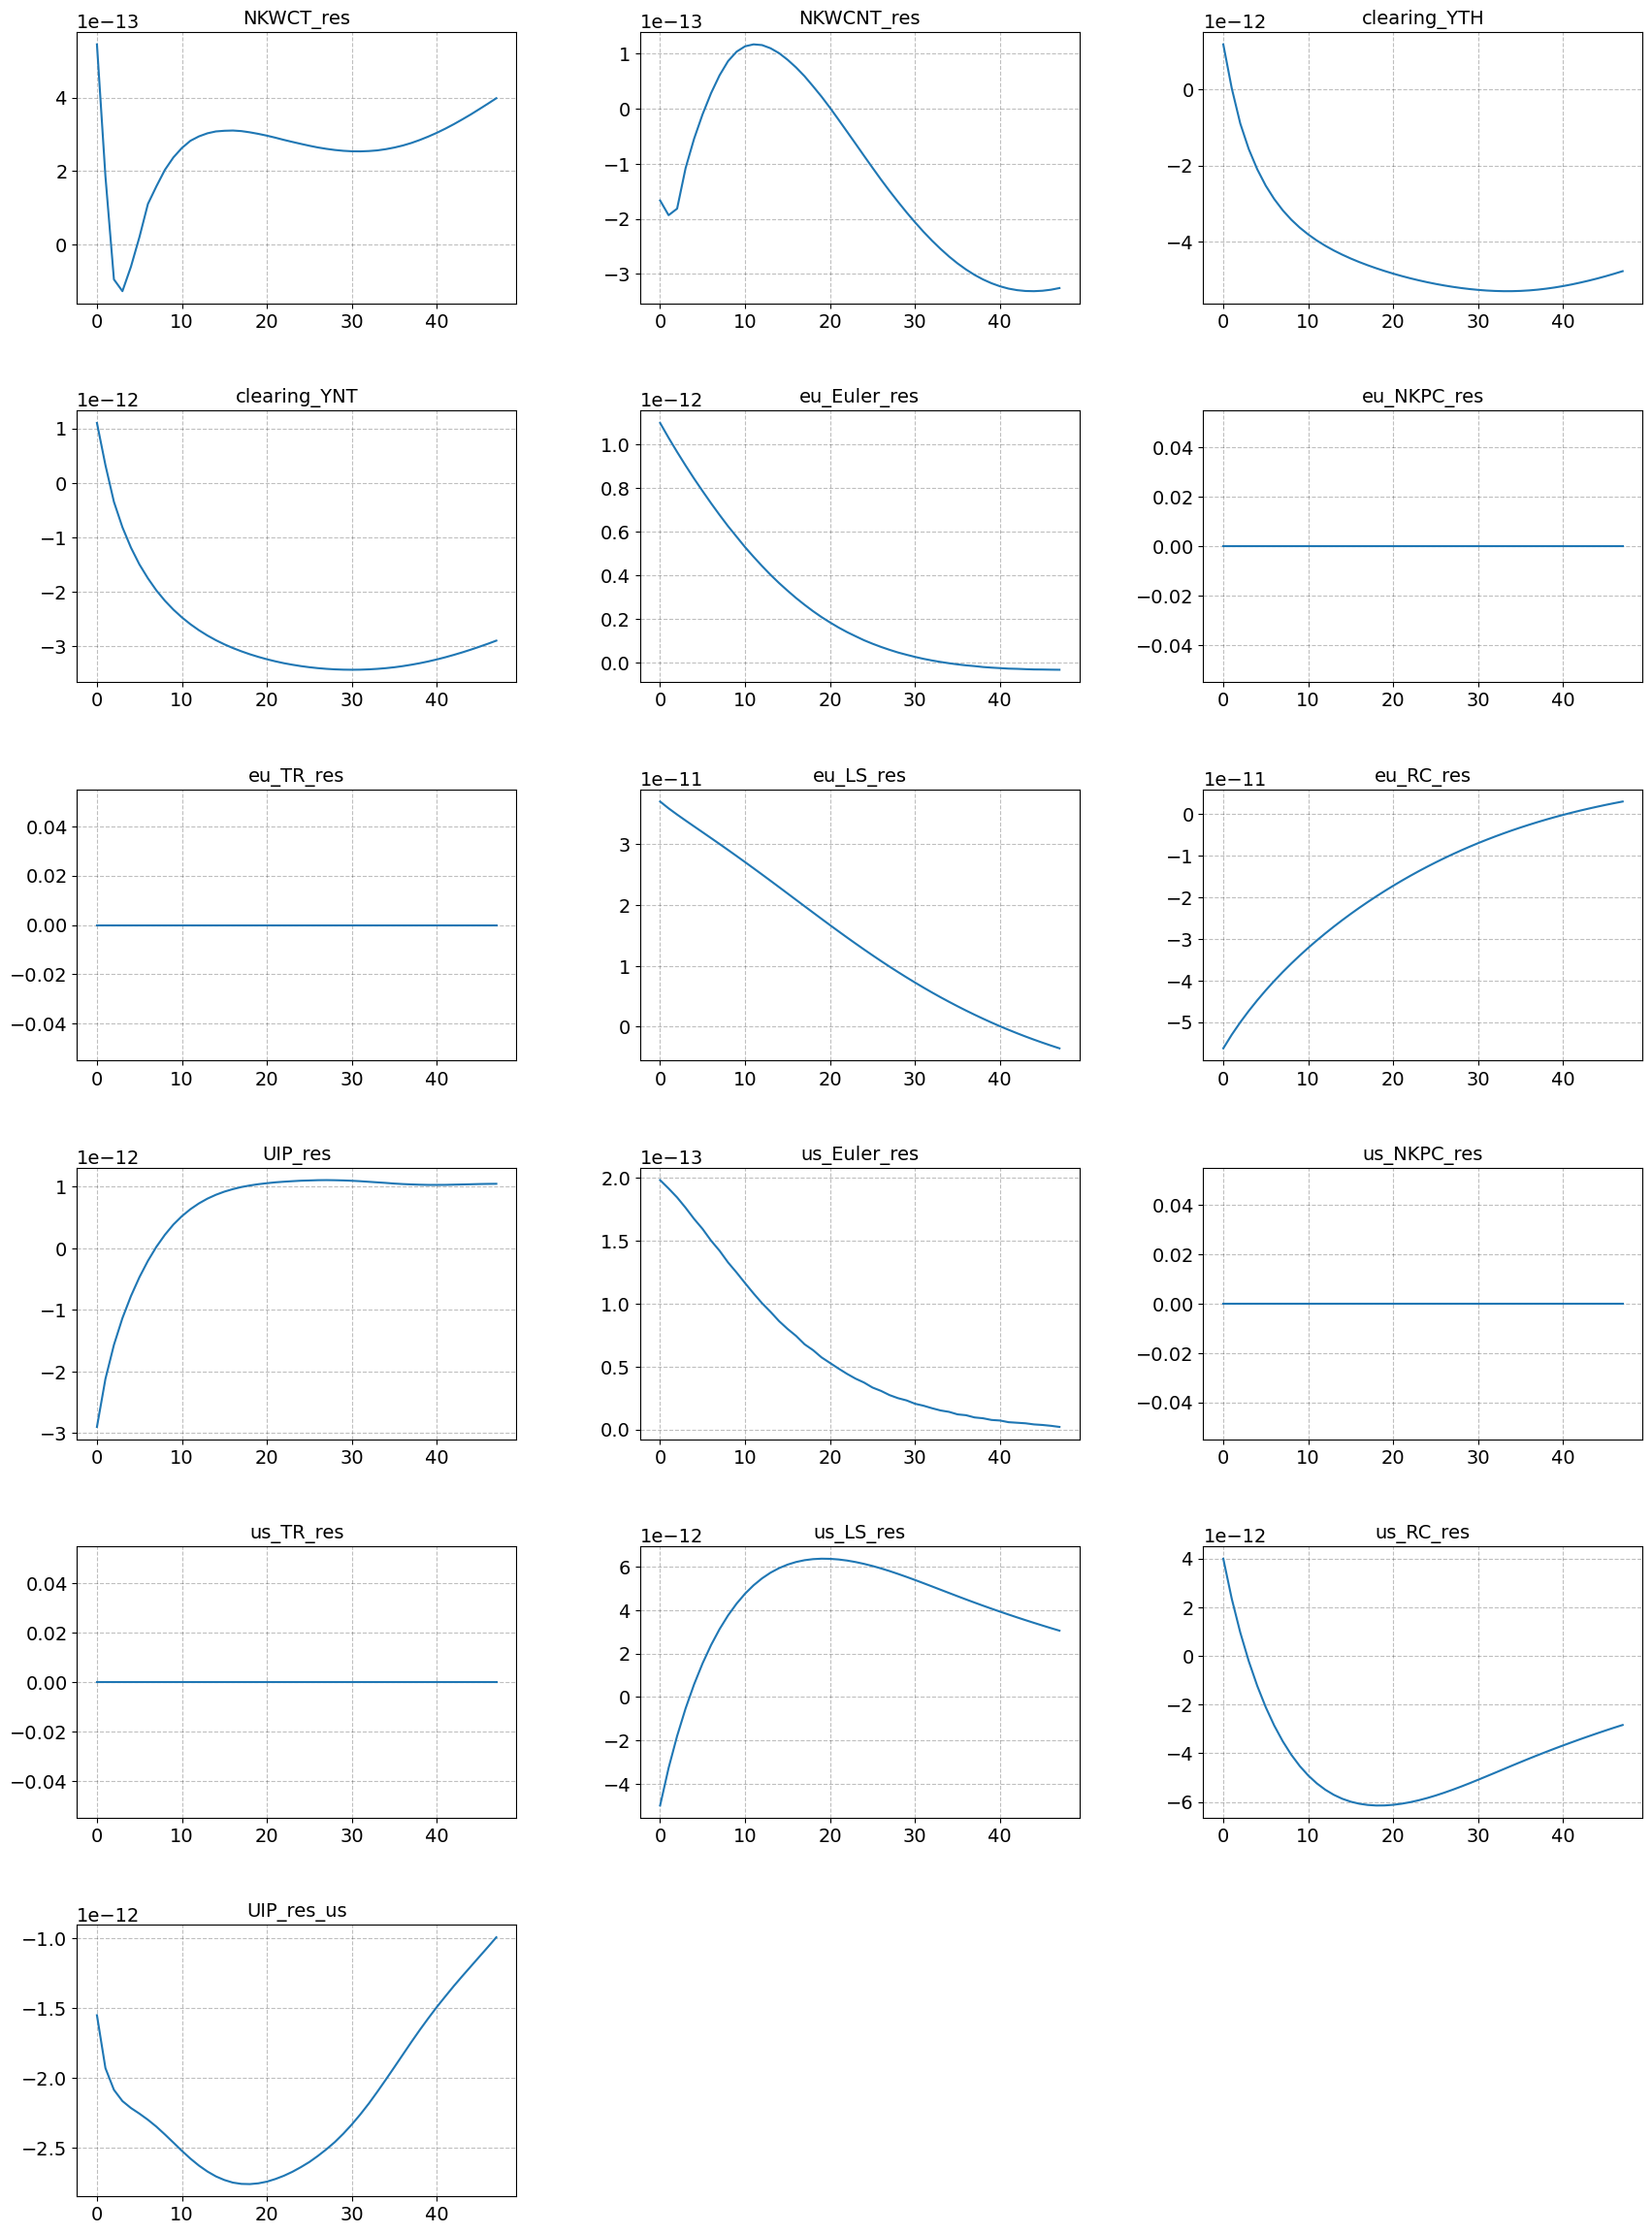

In [16]:

print("max |tau_m|:", np.max(np.abs(m_tau_m.path.tau_m)))


paths = ['M_eu_s','M_us_s','GDP','YTH','YNT','C_hh','C_TH_hh','C_NT_hh','CT','CTH','CTF','CNT','CTH_eu_s','ra','inc_TH','inc_NT','tau','Q','E','NFA','Walras']
lvl_value=['r','NFA','Walras','i_shock', 'i_shock_eu', 'i_shock_us', 'piM_us_us', 'piM_eu_eu', 'tau_x', 'tau_m']
m_tau_m.show_IRFs(paths,lvl_value=lvl_value,T_max=48,ncols=3)

### Scenario 4 — Full tariff war (both simultaneous)

In [17]:
m_war = model.copy()
m_war.par.jump_tau_x = TARIFF_SIZE
m_war.par.rho_tau_x  = TARIFF_RHO
m_war.par.jump_tau_m = TARIFF_SIZE
m_war.par.rho_tau_m  = TARIFF_RHO

m_war.find_transition_path(shocks=['tau_x', 'tau_m'], do_print=False, do_end_check=False)

MemoryError: Unable to allocate 1.91 MiB for an array with shape (500, 500) and data type float64

## 5. IRF comparison

Variables shown in **log-deviations from SS** unless listed in `lvl_value` (rates, prices, tariff paths).

In [ ]:
# Variables shown in levels (rates and prices — not log-deviations)
lvl_value = ['pi', 'pi_eu', 'pi_us', 'tau', 'r', 'ra', 'i', 'i_eu', 'i_us',
             'tau_m', 'tau_x', 'NFA', 'Walras', 'UIP_res', 'UIP_res_us']

# Models and labels for comparison
models = [m_tau_x, m_tau_m, m_war]
labels = ['US tariff only (τ_x)', 'DK/EA retaliation only (τ_m)', 'Full tariff war']

### Shocks

In [ ]:
# Verify tariff paths look correct (AR(1) decay)
model.compare_IRFs(
    models, labels,
    varnames=['tau_x', 'tau_m'],
    lvl_value=lvl_value,
    T_max=60, ncols=2,
    do_targets=False
)
plt.suptitle('Tariff shock paths', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(folder, 'tariff_shocks.png'), dpi=150, bbox_inches='tight')

### Output and consumption

In [ ]:
model.compare_IRFs(
    models, labels,
    varnames=['GDP', 'YTH', 'YNT', 'C_hh'],
    lvl_value=lvl_value,
    T_max=60, ncols=4,
    do_targets=False
)
plt.suptitle('Output and consumption', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(folder, 'output_consumption.png'), dpi=150, bbox_inches='tight')

### Trade — exports and materials prices

In [ ]:
model.compare_IRFs(
    models, labels,
    varnames=['CTH_us_s', 'CTH_eu_s', 'PM_us', 'PM'],
    lvl_value=lvl_value,
    T_max=60, ncols=4,
    do_targets=False
)
plt.suptitle('Trade: exports and materials prices', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(folder, 'trade_materials.png'), dpi=150, bbox_inches='tight')

### Prices and exchange rates

In [ ]:
model.compare_IRFs(
    models, labels,
    varnames=['pi', 'Q_us', 'Q', 'E'],
    lvl_value=lvl_value,
    T_max=60, ncols=4,
    do_targets=False
)
plt.suptitle('Prices and exchange rates', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(folder, 'prices_exchange.png'), dpi=150, bbox_inches='tight')

### Fiscal and household income

In [ ]:
model.compare_IRFs(
    models, labels,
    varnames=['tau', 'B', 'inc_TH', 'inc_NT'],
    lvl_value=lvl_value,
    T_max=60, ncols=4,
    do_targets=False
)
plt.suptitle('Fiscal policy and household income', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(folder, 'fiscal_income.png'), dpi=150, bbox_inches='tight')

### External balance

In [ ]:
model.compare_IRFs(
    models, labels,
    varnames=['NX', 'NFA', 'CA'],
    lvl_value=lvl_value,
    T_max=60, ncols=3,
    do_targets=False
)
plt.suptitle('External balance', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(folder, 'external_balance.png'), dpi=150, bbox_inches='tight')

### EU and US responses (spillovers)

In [ ]:
model.compare_IRFs(
    models, labels,
    varnames=['Y_eu', 'pi_eu', 'Y_us', 'pi_us'],
    lvl_value=lvl_value,
    T_max=60, ncols=4,
    do_targets=False
)
plt.suptitle('EU and US responses (spillovers via materials costs)', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(folder, 'eu_us_spillovers.png'), dpi=150, bbox_inches='tight')

## 6. Revenue mode comparison

Toggle `par.tariff_rev_lumpsum` to compare how revenue allocation affects the results.
- **Mode A** (default, `False`): revenue reduces govt debt → fiscal rule lowers taxes over time
- **Mode B** (`True`): revenue rebated lump-sum equally to all households

In [ ]:
# Full tariff war — fiscal rule (Mode A, default)
m_war_A = model.copy()
m_war_A.par.jump_tau_x = TARIFF_SIZE
m_war_A.par.rho_tau_x  = TARIFF_RHO
m_war_A.par.jump_tau_m = TARIFF_SIZE
m_war_A.par.rho_tau_m  = TARIFF_RHO
m_war_A.par.tariff_rev_lumpsum = False  # Mode A: revenue into govt budget
m_war_A.find_transition_path(shocks=['tau_x', 'tau_m'], do_print=False, do_end_check=False)

# Full tariff war — lump-sum rebate (Mode B)
m_war_B = model.copy()
m_war_B.par.jump_tau_x = TARIFF_SIZE
m_war_B.par.rho_tau_x  = TARIFF_RHO
m_war_B.par.jump_tau_m = TARIFF_SIZE
m_war_B.par.rho_tau_m  = TARIFF_RHO
m_war_B.par.tariff_rev_lumpsum = True   # Mode B: lump-sum to households
m_war_B.find_transition_path(shocks=['tau_x', 'tau_m'], do_print=False, do_end_check=False)

In [ ]:
model.compare_IRFs(
    [m_war_A, m_war_B],
    ['Fiscal rule (Mode A)', 'Lump-sum rebate (Mode B)'],
    varnames=['GDP', 'C_hh', 'inc_TH', 'inc_NT', 'tau', 'B'],
    lvl_value=lvl_value,
    T_max=60, ncols=3,
    do_targets=False
)
plt.suptitle('Revenue mode: fiscal rule vs lump-sum (full tariff war)', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(folder, 'revenue_mode_comparison.png'), dpi=150, bbox_inches='tight')